In [1]:
from openpyxl import Workbook
from openpyxl import load_workbook
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os
import itertools
from datetime import datetime
import joblib
from scipy import stats
from sklearn.decomposition import PCA
#from tqdm.notebook import tqdm
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from matplotlib import font_manager as fm
import openpyxl
import shutil
import subprocess

In [2]:
import logging
import os
from datetime import datetime


# 로그 생성
logger = logging.getLogger()

# 로그의 출력 기준 설정
logger.setLevel(logging.INFO)

# log 출력 형식
formatter = logging.Formatter('%(asctime)s[%(levelname)s]: %(message)s')

while logger.hasHandlers():
    logger.removeHandler(logger.handlers[0])
    
    
# log 출력
stream_handler = logging.StreamHandler()
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)


In [495]:
df_exp = pd.read_csv(f'SST_PV_cfos_Summary_Jin_Mehdi_Nov24_exp.csv')
df_veh = pd.read_csv(f'SST_PV_cfos_Summary_Jin_Mehdi_Nov24_veh.csv')

In [496]:
def proprocess(_df):        
    _df = _df.drop([a for a in _df.columns if a.startswith("Unnamed")], axis=1)
    _df = _df.drop([a for a in _df.columns if a.startswith("average")], axis=1)
    _df = _df.drop([a for a in _df.columns if a.startswith("sem")], axis=1)
    _df = _df.drop([a for a in _df.columns if a.startswith("%error")], axis=1)
    #df_exp = df_exp.drop([a for a in df_exp.columns if a.endswith("fraction")], axis=1)
    _df.drop(_df[_df['TG number'] == 1329].index, inplace=True)
    _df['Region ID'] = _df['Region ID'].astype(int)
    _df['TG number'] = _df['TG number'].astype(int)
    for _c in _df.columns:
        if _c.endswith('SS/cfos fraction'):
            _df = _df.rename(columns={_c: _c.replace('SS/cfos fraction','SST/cfos fraction')})
            
    _df = _df.replace('#DIV/0!',0.0)
    for _c in _df.columns[3:]:
        _df[_c] = _df[_c].astype(float)
    return _df

In [497]:
df_exp = proprocess(df_exp)
df_veh = proprocess(df_veh)

In [499]:
df_exp

,TG number,Region ID,Region name,A0245_cor_SST,A0245_sag_SST,A0247_cor_SST,A0247_sag_SST,A0249_cor_SST,A0249_sag_SST,A0245_cor_PV,...,A0247_cor_SST-PV/cfos fraction,A0247_sag_SST-PV/cfos fraction,A0249_cor_SST-PV/cfos fraction,A0249_sag_SST-PV/cfos fraction,A0245_cor_cfos total,A0245_sag_cfos total,A0247_cor_cfos total,A0247_sag_cfos total,A0249_cor_cfos total,A0249_sag_cfos total
0,1,0,Clear Label,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,997,root,0.008358,0.000002,0.019015,0.005307,0.003588,0.005521,0.003362,...,29.044834,21.576355,24.172662,56.179775,0.006368,0.003177,0.006971,0.014907,0.015803,0.009787
2,3,8,Basic cell groups and regions,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4,567,Cerebrum,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,5,688,Cerebral cortex,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1323,1324,49,intraparafloccular fissure,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1324,1325,57,paramedian sulcus,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1325,1326,65,parafloccular sulcus,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1326,1327,624,Interpeduncular fossa,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [498]:
print(len(df_exp))
print(len(df_veh))

1328
1328


In [500]:
print("the number of regions with all zero")

df_exp_zeros = df_exp[df_exp[df_exp.columns[3:]].sum(axis=1) == 0.0]
df_veh_zeros = df_veh[df_veh[df_veh.columns[3:]].sum(axis=1) == 0.0]

print(len(df_exp_zeros))
print(len(df_veh_zeros))


the number of regions with all zero
655
646


In [517]:
df_exp_zeros['Region ID']


0               0
2               8
3             567
4             688
5             695
          ...    
1323           49
1324           57
1325           65
1326          624
1327    304325711
Name: Region ID, Length: 655, dtype: int64

In [519]:
zero_region_ids_exp_1_veh_1 = list(set(df_exp_zeros['Region ID'].values).intersection(set(df_veh_zeros['Region ID'].values)))
zero_region_ids_exp_1_veh_0 = list(set(df_exp_zeros['Region ID'].values).difference(set(df_veh_zeros['Region ID'].values)))
zero_region_ids_exp_0_veh_1 = list(set(df_veh_zeros['Region ID'].values).difference(set(df_exp_zeros['Region ID'].values)))
print(len(zero_region_ids_exp_1_veh_1))
print(len(zero_region_ids_exp_1_veh_0),zero_region_ids_exp_1_veh_0)
print(len(zero_region_ids_exp_0_veh_1),zero_region_ids_exp_0_veh_1)


645
10 [318, 198, 230, 206, 207, 846, 177, 599626927, 763, 222]
1 [382]


In [508]:
zero_region_ids_exp_1_veh_1 = list(set(df_exp_zeros.index).intersection(set(df_veh_zeros.index)))
zero_region_ids_exp_1_veh_0 = list(set(df_exp_zeros.index).difference(set(df_veh_zeros.index)))
zero_region_ids_exp_0_veh_1 = list(set(df_veh_zeros.index).difference(set(df_exp_zeros.index)))
print(len(zero_region_ids_exp_1_veh_1))
print(len(zero_region_ids_exp_1_veh_0),zero_region_ids_exp_1_veh_0)
print(len(zero_region_ids_exp_0_veh_1),zero_region_ids_exp_0_veh_1)


645
10 [996, 938, 746, 1100, 911, 916, 1012, 1013, 1014, 1209]
1 [458]


In [523]:
print(df_exp[df_exp['Region ID'].isin(zero_region_ids_exp_1_veh_0)]['Region name'])
print(df_veh[df_veh['Region ID'].isin(zero_region_ids_exp_0_veh_1)]['Region name'])

#print(df_veh.loc[zero_region_ids_exp_0_veh_1]['Region name'])

746     Vascular organ of the lamina terminalis
911             Posterodorsal tegmental nucleus
916                         Supragenual nucleus
938                               Area postrema
996                           Nucleus of Roller
1012                       Nucleus raphe magnus
1013                     Nucleus raphe pallidus
1014                     Nucleus raphe obscurus
1100                            Dentate nucleus
1209                      pyramidal decussation
Name: Region name, dtype: object
458    Field CA1
Name: Region name, dtype: object


,TG number,Region ID,Region name,A0245_cor_SST,A0245_sag_SST,A0247_cor_SST,A0247_sag_SST,A0249_cor_SST,A0249_sag_SST,A0245_cor_PV,...,A0247_cor_SST-PV/cfos fraction,A0247_sag_SST-PV/cfos fraction,A0249_cor_SST-PV/cfos fraction,A0249_sag_SST-PV/cfos fraction,A0245_cor_cfos total,A0245_sag_cfos total,A0247_cor_cfos total,A0247_sag_cfos total,A0249_cor_cfos total,A0249_sag_cfos total
1,2,997,root,0.008358,0.000002,0.019015,0.005307,0.003588,0.005521,0.003362,...,29.044834,21.576355,24.172662,56.179775,0.006368,0.003177,0.006971,0.014907,0.015803,0.009787
8,9,68,"Frontal pole, layer 1",0.012596,0.000000,0.016198,0.009376,0.000000,0.018361,0.000166,...,0.000000,10.769231,0.000000,0.000000,0.002527,0.005808,0.000929,0.007062,0.000000,0.007150
9,10,667,"Frontal pole, layer 2/3",0.014170,0.000000,0.031523,0.013904,0.000000,0.013156,0.059094,...,0.000000,20.512821,0.000000,9.860465,0.064396,0.069689,0.002211,0.044929,0.000000,0.048105
10,11,526157192,"Frontal pole, layer 5",0.034079,0.008521,0.051969,0.026382,0.000000,0.017232,0.033869,...,0.000000,49.821301,0.000000,31.146497,0.052773,0.069245,0.003425,0.025373,0.000000,0.057756
11,12,526157196,"Frontal pole, layer 6a",0.033035,0.000000,0.034205,0.025626,0.024883,0.017303,0.005922,...,10.464189,21.685454,0.000000,0.611176,0.031625,0.045930,0.012393,0.018972,0.025558,0.044956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1297,1298,108,choroid plexus,0.000008,0.000000,0.000417,0.000487,0.000395,0.000895,0.000000,...,0.000000,57.647059,88.778055,46.575342,0.001453,0.000776,0.001817,0.034943,0.018183,0.024609
1300,1301,129,third ventricle,0.002438,0.000027,0.005611,0.001500,0.001730,0.000344,0.000182,...,18.421053,33.720930,100.000000,83.823529,0.006123,0.001452,0.006432,0.022360,0.012167,0.019190
1301,1302,140,cerebral aqueduct,0.000000,0.000000,0.006094,0.002993,0.002298,0.000000,0.000000,...,0.000000,3.685259,0.000000,0.000000,0.003954,0.000000,0.000000,0.008335,0.010999,0.011499
1302,1303,145,fourth ventricle,0.000000,0.000000,0.000000,0.003733,0.000000,0.000544,0.000000,...,0.000000,40.082988,0.000000,50.000000,0.000000,0.003581,0.000000,0.011324,0.000000,0.002392


In [527]:
df_exp = df_exp[~df_exp['Region ID'].isin(zero_region_ids_exp_1_veh_1)]
df_veh = df_veh[~df_veh['Region ID'].isin(zero_region_ids_exp_1_veh_1)]

In [528]:
print(len(df_exp))
print(len(df_veh))

683
683


In [529]:
subject_id_exp = list(set([a.split("_")[0] for a in df_exp.columns[3:]]))
subject_id_veh = list(set([a.split("_")[0] for a in df_veh.columns[3:]]))
print(subject_id_exp)
print(subject_id_veh)

['A0247', 'A0245', 'A0249']
['A0244', 'A0242', '1049']


In [530]:
cut_method_list = list(set([a.split("_")[1] for a in df_exp.columns[3:]]))
color_list = list(set([a.split("_")[2] for a in df_exp.columns[3:]]))

print(cut_method_list)
print(color_list)

#color_list = ['PV','cfos','SST']

['cor', 'sag']
['PV', 'PV/cfos fraction', 'cfos', 'cfos total', 'SST-PV-cfos', 'SST-cfos', 'PV-cfos', 'SST/cfos fraction', 'SST-PV', 'SST', 'SST-PV/cfos fraction']


In [531]:
df_exp.drop(['TG number','Region name','Region ID'] ,axis=1, inplace=True)

In [532]:

df_total = pd.concat([df_exp,df_veh], axis=1)
df_total.drop(['TG number','Region name'] ,axis=1, inplace=True)
df_total.set_index('Region ID', inplace=True)
df_total = df_total.T
df_total['veh_exp'] = [1 if a.split('_')[0] in subject_id_exp else 0 for a in df_total.index]
df_total['cut_method'] = ['cor' if a.split('_')[1] == 'cor' else 'sag' for a in df_total.index]
df_total['color'] =[ a.split('_')[2] for a in df_total.index]

In [533]:
from itertools import product

dept_columns = []
for _a in list(product(cut_method_list, color_list)):
    dept_columns.append("_".join(_a))
dept_columns
 


[
    'cor_PV',
    'cor_PV/cfos fraction',
    'cor_cfos',
    'cor_cfos total',
    'cor_SST-PV-cfos',
    'cor_SST-cfos',
    'cor_PV-cfos',
    'cor_SST/cfos fraction',
    'cor_SST-PV',
    'cor_SST',
    'cor_SST-PV/cfos fraction',
    'sag_PV',
    'sag_PV/cfos fraction',
    'sag_cfos',
    'sag_cfos total',
    'sag_SST-PV-cfos',
    'sag_SST-cfos',
    'sag_PV-cfos',
    'sag_SST/cfos fraction',
    'sag_SST-PV',
    'sag_SST',
    'sag_SST-PV/cfos fraction'
]

In [534]:
df_total[df_total.index.str.endswith(dept_col)]

Region ID,997,68,667,526157192,526157196,526322264,320,943,648,844,...,81,98,108,129,140,145,153,veh_exp,cut_method,color
A0245_sag_SST-PV/cfos fraction,0.000000,0.000000,0.000000,0.000000,1.966546,0.0,0.000000,0.249377,0.263227,1.022271,...,0.000000,0.0,0.000000,0.000000,0.000000,0.593220,1.248399,1,sag,SST-PV/cfos fraction
A0247_sag_SST-PV/cfos fraction,21.576355,10.769231,20.512821,49.821301,21.685454,0.0,80.000000,13.996317,9.982238,19.677671,...,7.459207,0.0,57.647059,33.720930,3.685259,40.082988,39.192399,1,sag,SST-PV/cfos fraction
A0249_sag_SST-PV/cfos fraction,56.179775,0.000000,9.860465,31.146497,0.611176,0.0,93.396226,16.815597,19.603399,18.707900,...,0.000000,0.0,46.575342,83.823529,0.000000,50.000000,0.000000,1,sag,SST-PV/cfos fraction
A0244_sag_SST-PV/cfos fraction,17.996454,0.000000,15.189873,7.052298,6.219512,0.0,4.651163,26.167728,18.631732,7.965812,...,7.777778,0.0,1.117318,0.000000,0.000000,6.656805,0.000000,0,sag,SST-PV/cfos fraction
A0242_sag_SST-PV/cfos fraction,0.892857,0.000000,32.348804,1.689546,0.000000,0.0,62.500000,27.959548,26.397516,9.761550,...,89.583333,0.0,100.000000,0.000000,0.000000,0.000000,0.000000,0,sag,SST-PV/cfos fraction
1049_sag_SST-PV/cfos fraction,18.457300,0.000000,3.076923,16.963623,15.995066,0.0,0.000000,15.319747,9.551495,10.344149,...,31.034483,0.0,0.000000,0.000000,0.000000,2.842524,2.640264,0,sag,SST-PV/cfos fraction


In [535]:
ind_col = 'Sphingobacterium rhinocerotis'
dept_col = '노화최종판정'
min_p_value = 0.01


_row_list = []

for dept_col in tqdm(dept_columns):

    _df = df_total[df_total.index.str.endswith(dept_col)]

    
    logger.info(dept_col)
    group_exp = _df[_df['veh_exp'] == 0]
    group_veh = _df[_df['veh_exp'] == 1]
    
    for ind_col in _df.columns:
        if ind_col == 'veh_exp':
            break
        #print(group_exp[ind_col])
        #print(group_exp[ind_col])
        t_stat, p_value = stats.ttest_ind(group_exp[ind_col], group_veh[ind_col])

        if np.isnan(p_value):
            continue

        if p_value > min_p_value:
            continue
        
        _row = {}
        #_row['dept'] = dept_col
        _row['cut_method'] = dept_col.split("_")[0]
        _row['color'] = dept_col.split("_")[1]
        #_row['dept_2'] = df.dtypes[dept_col].categories[1]
        _row['region_id'] = ind_col
        _row['region_name'] = G.nodes[ind_col]['name']        
        _row['t_stat'] = t_stat
        _row['pvalue'] = p_value
    
    
        _row_list.append(_row)
    


100%|██████████| 22/22 [00:11<00:00,  1.91it/s]


In [536]:
_ttest_df = pd.DataFrame(_row_list)
_ttest_df.to_csv('output/ttest.csv', encoding='utf-8', index=None)

In [537]:
_cut_method = 'cor'
_region_id_list = list(set(_ttest_df[_ttest_df['cut_method'] == _cut_method]['region_id'].values))

In [473]:
_df_melt.sort_values(by='Region ID')

,veh_exp,Region ID,value
0,1,"Posterior auditory area, layer 4(759)",0.000000
1,1,"Posterior auditory area, layer 4(759)",3.098451
2,1,"Posterior auditory area, layer 4(759)",0.000000
3,0,"Posterior auditory area, layer 4(759)",40.719714
4,0,"Posterior auditory area, layer 4(759)",33.487032
5,0,"Posterior auditory area, layer 4(759)",24.435129


<Figure size 640x480 with 0 Axes>

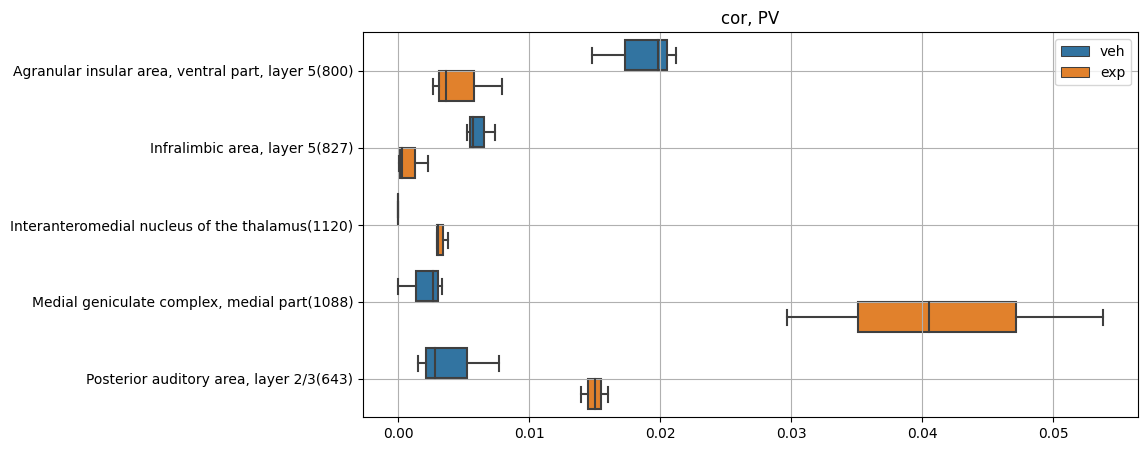

<Figure size 640x480 with 0 Axes>

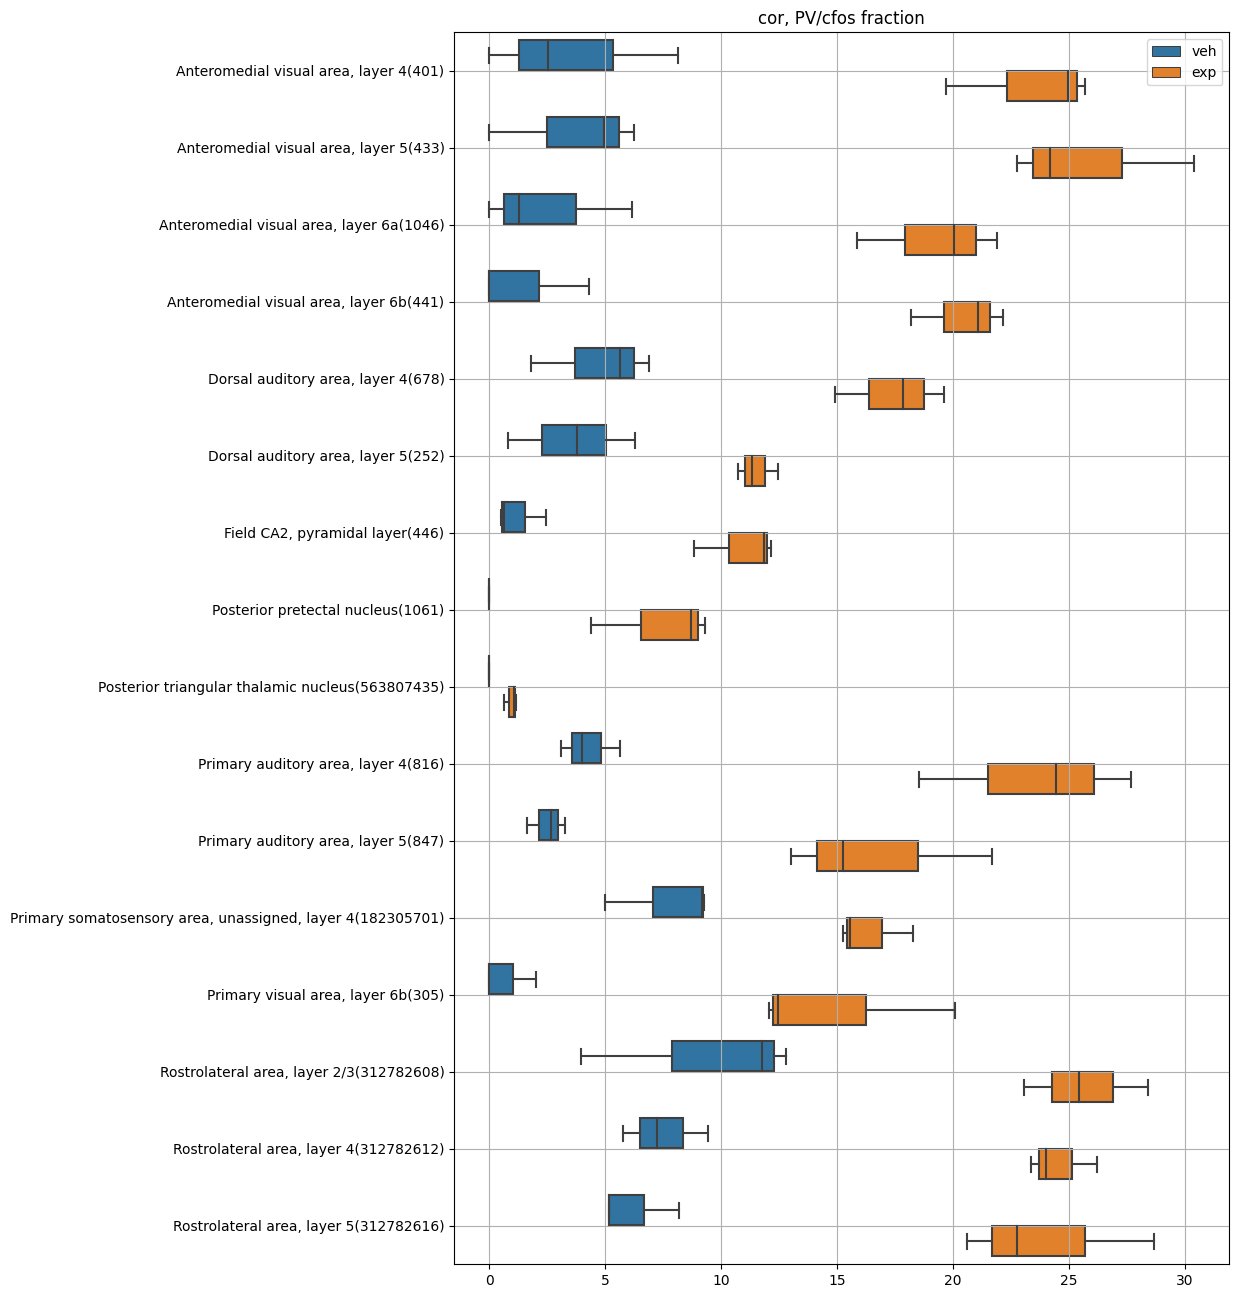

<Figure size 640x480 with 0 Axes>

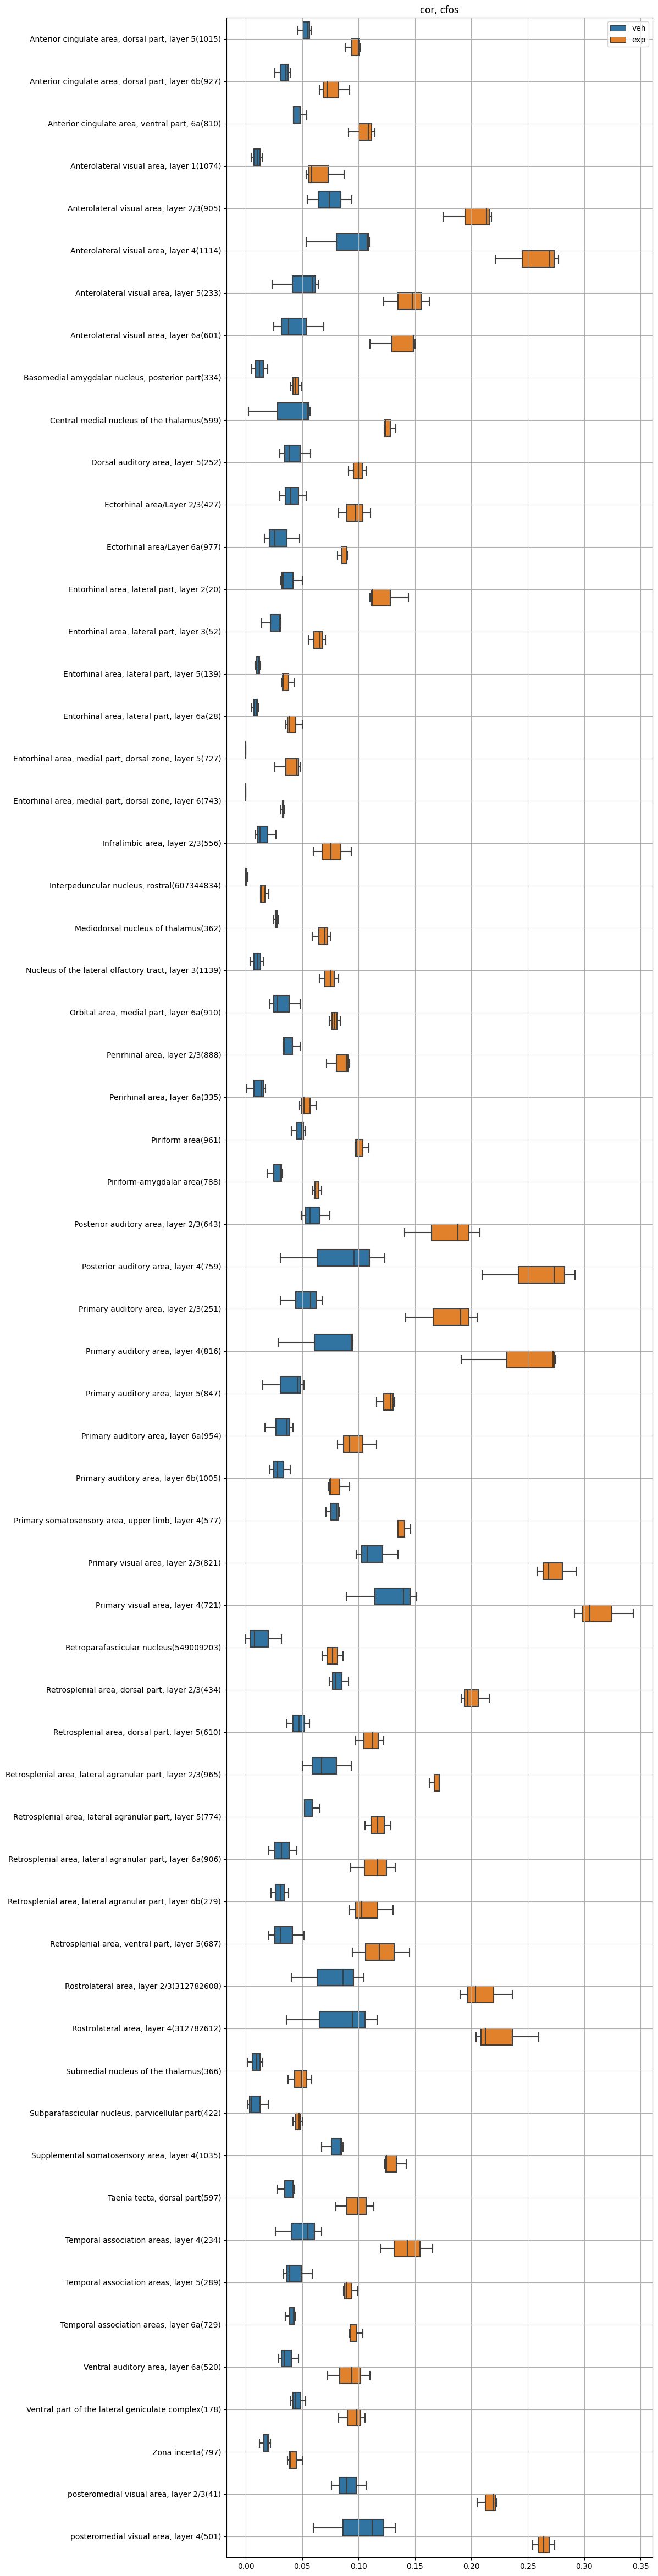

<Figure size 640x480 with 0 Axes>

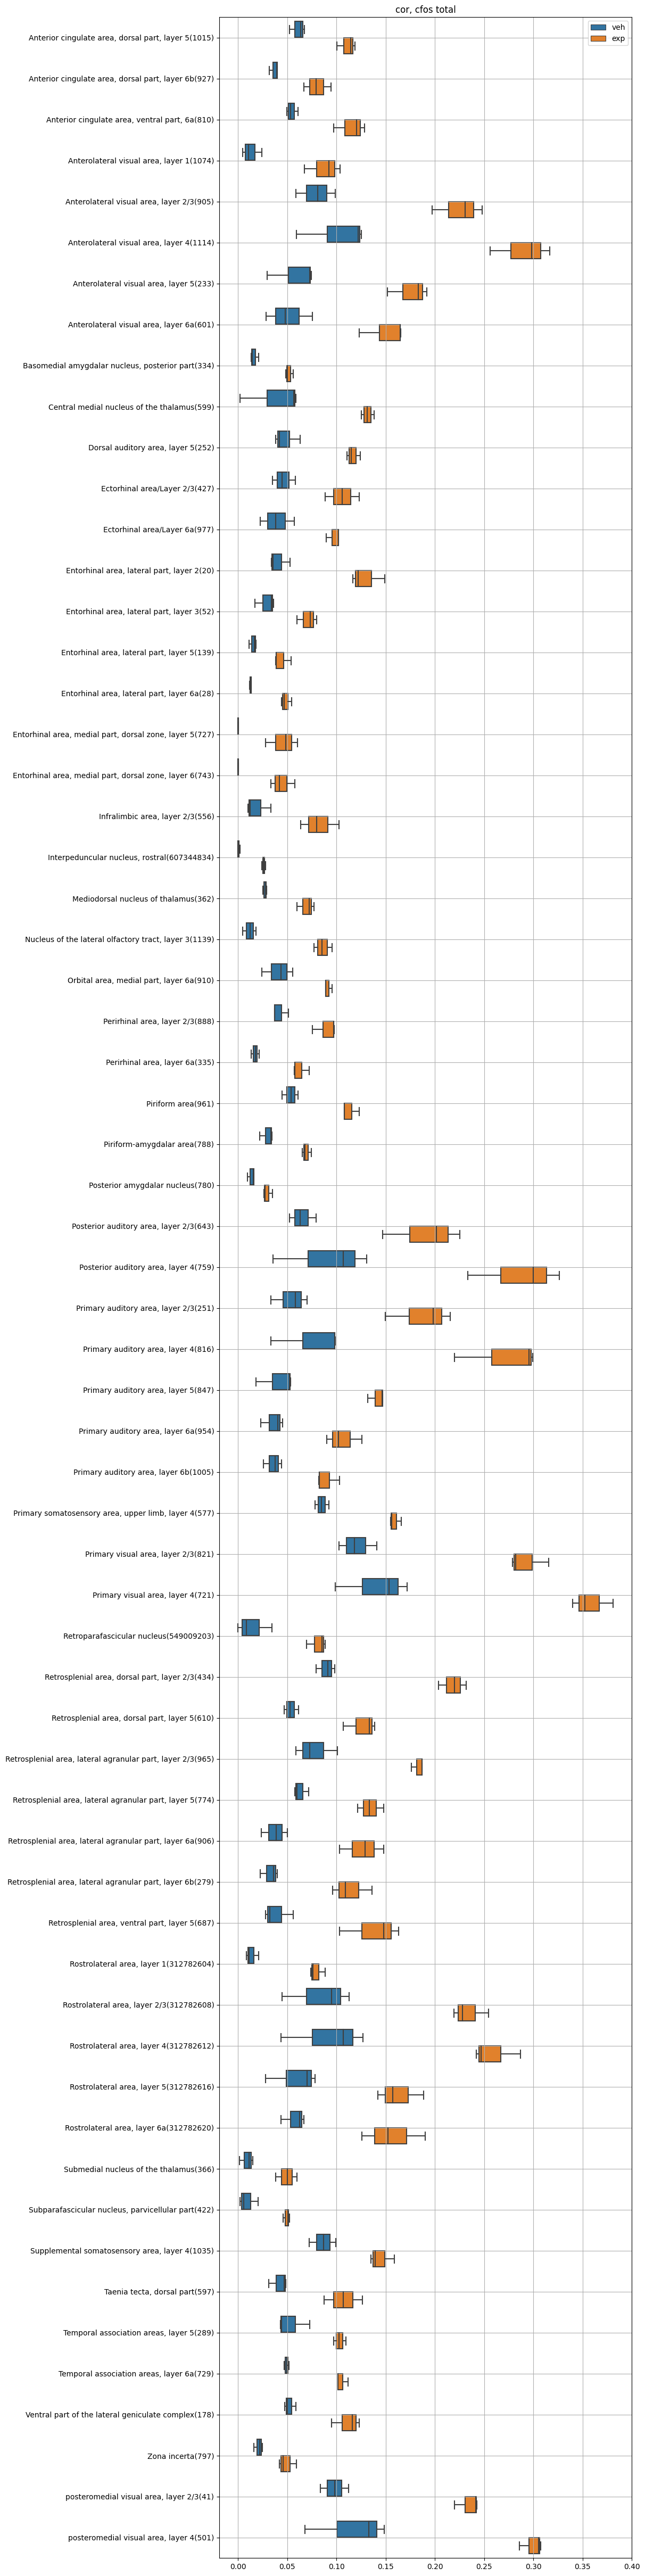

<Figure size 640x480 with 0 Axes>

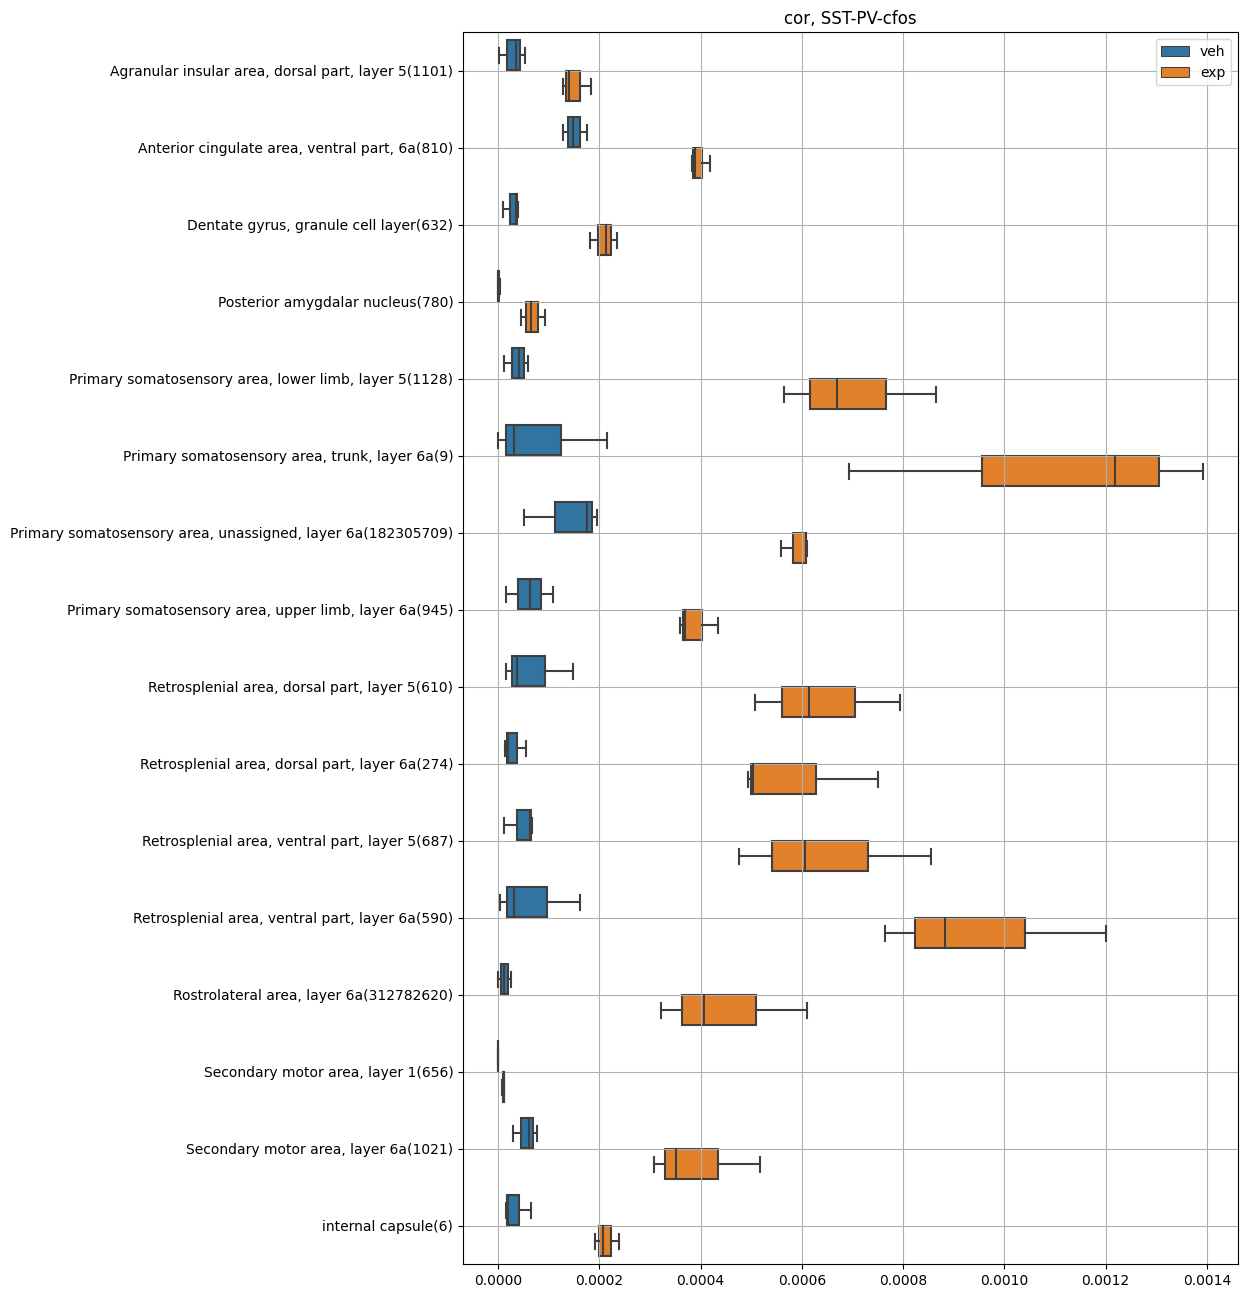

<Figure size 640x480 with 0 Axes>

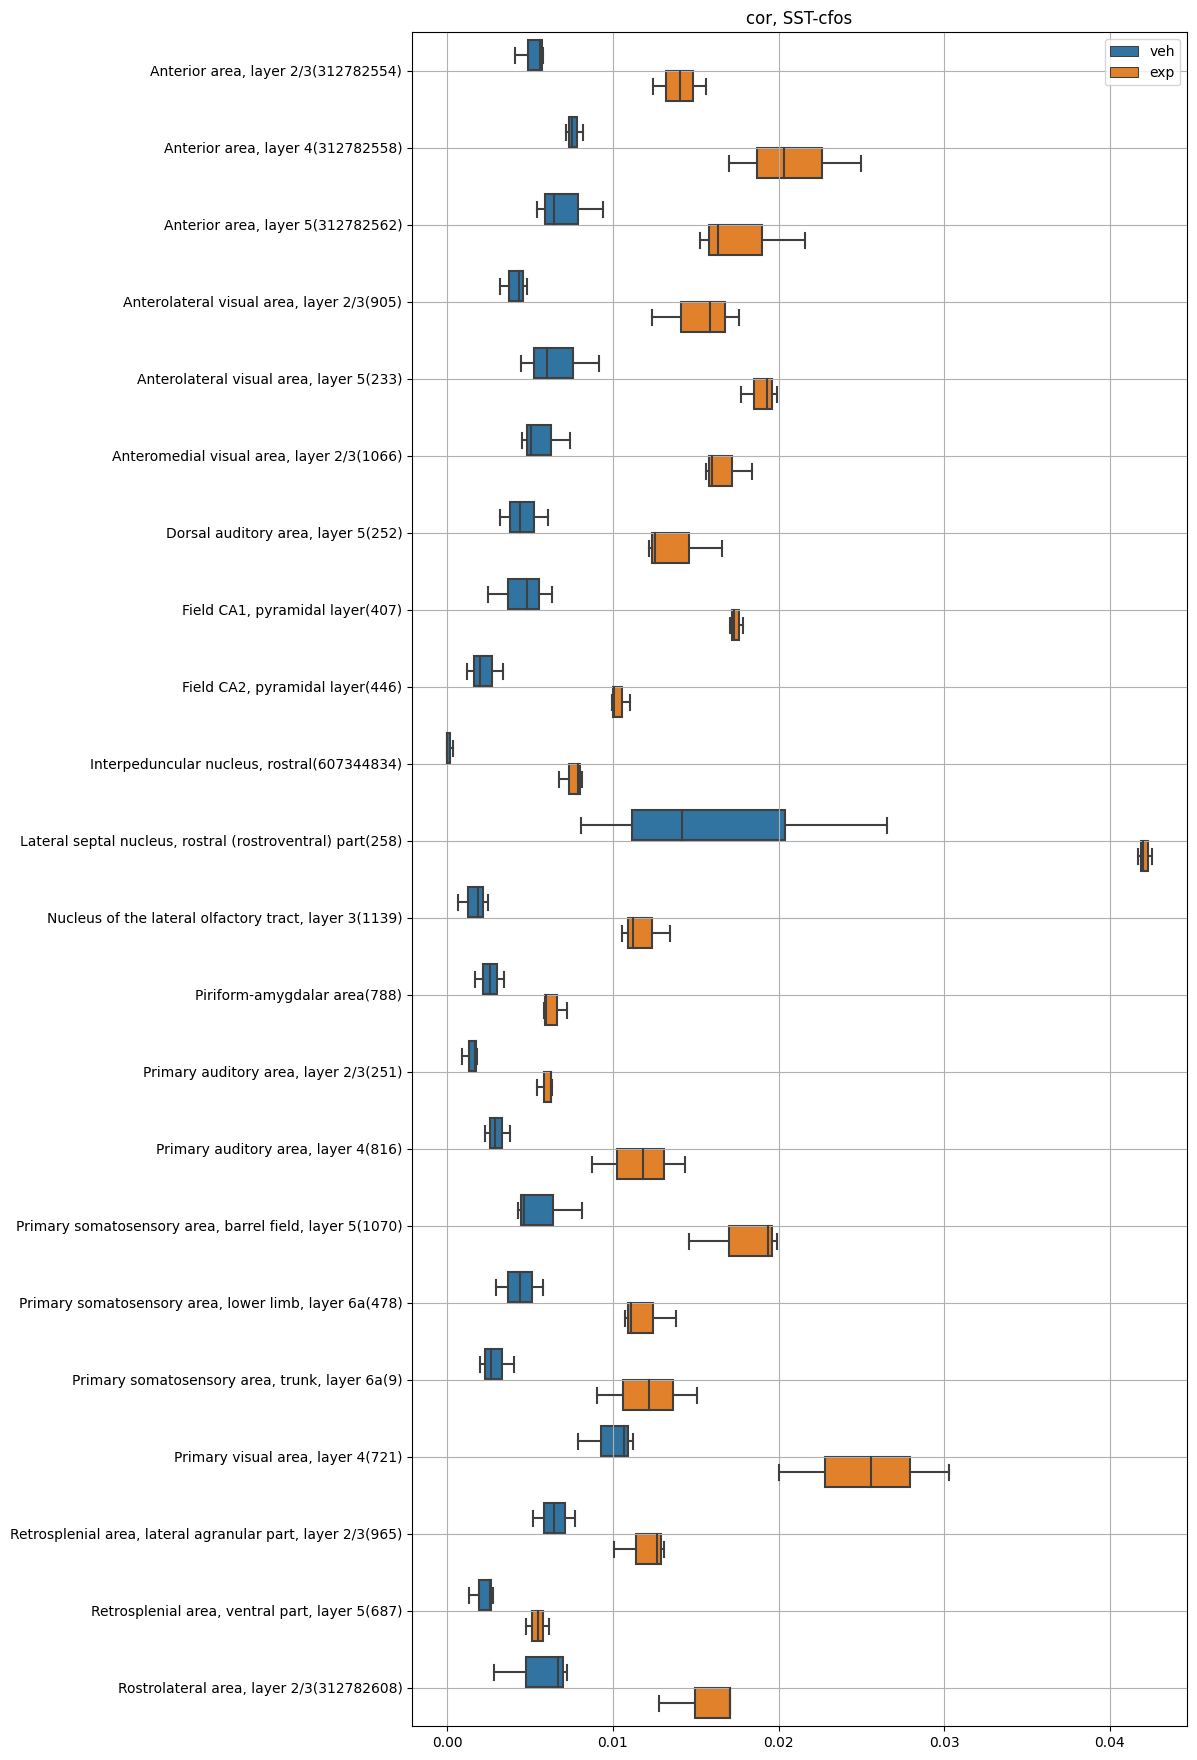

<Figure size 640x480 with 0 Axes>

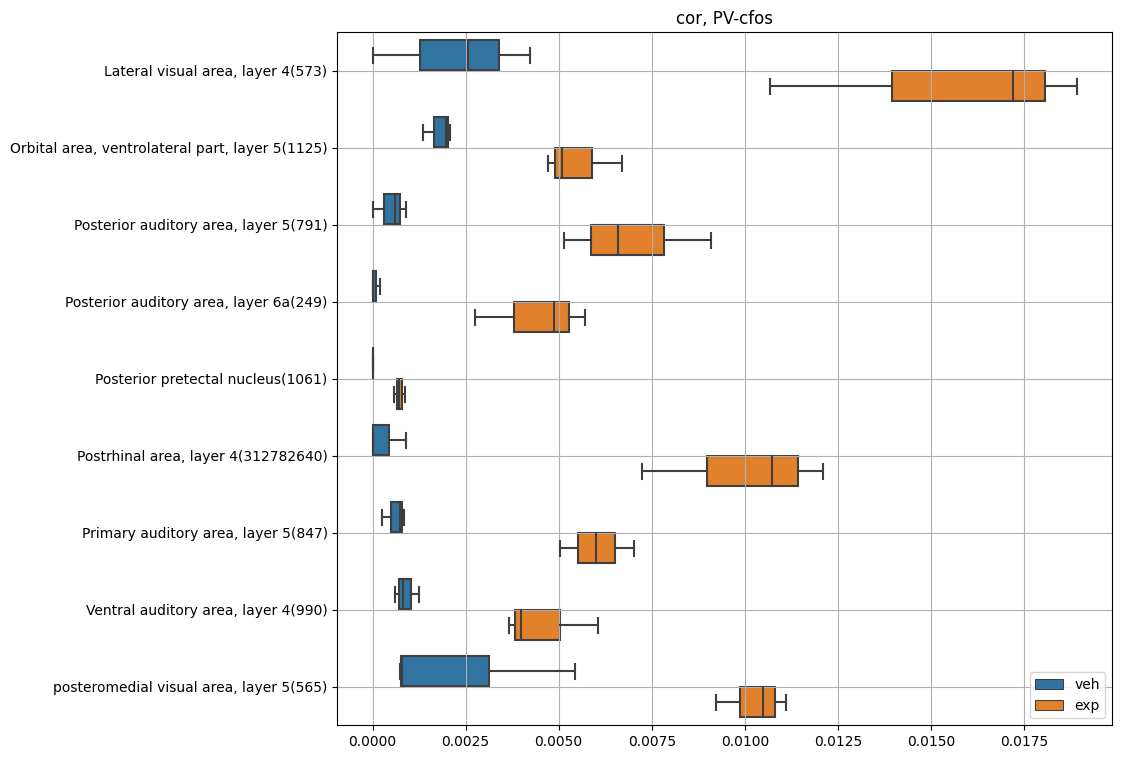

<Figure size 640x480 with 0 Axes>

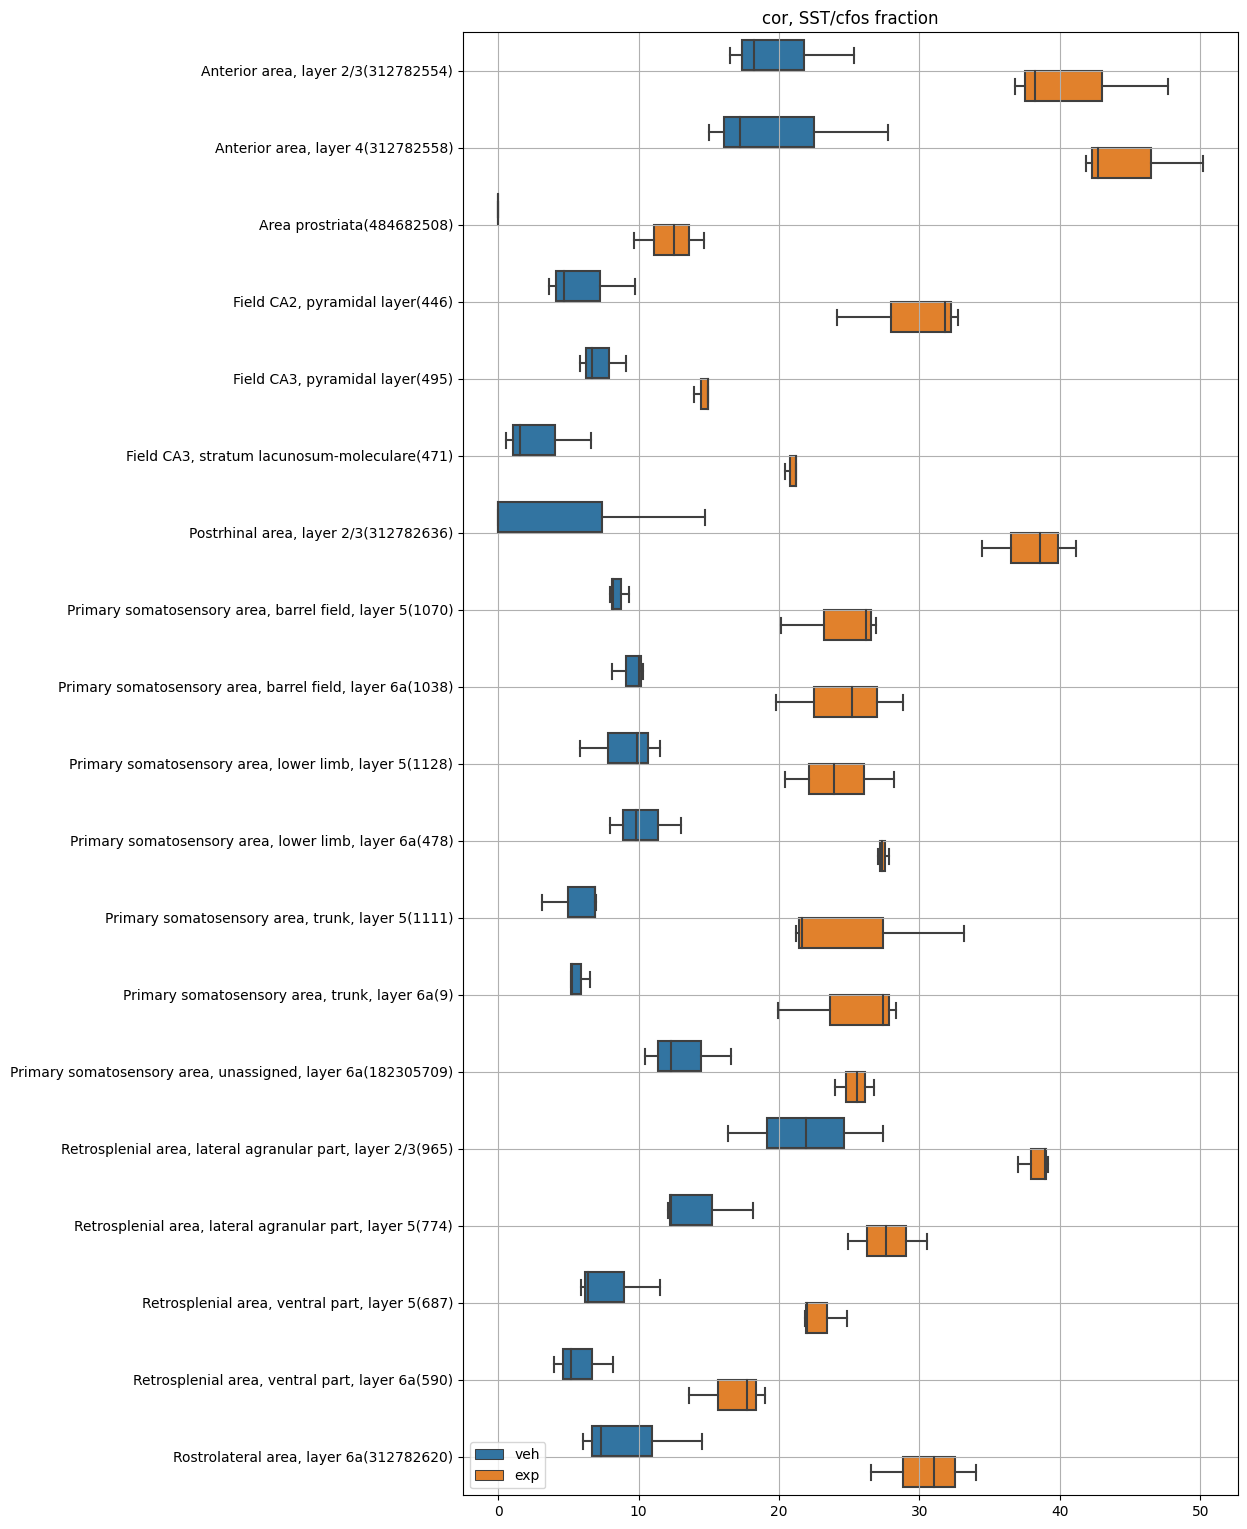

<Figure size 640x480 with 0 Axes>

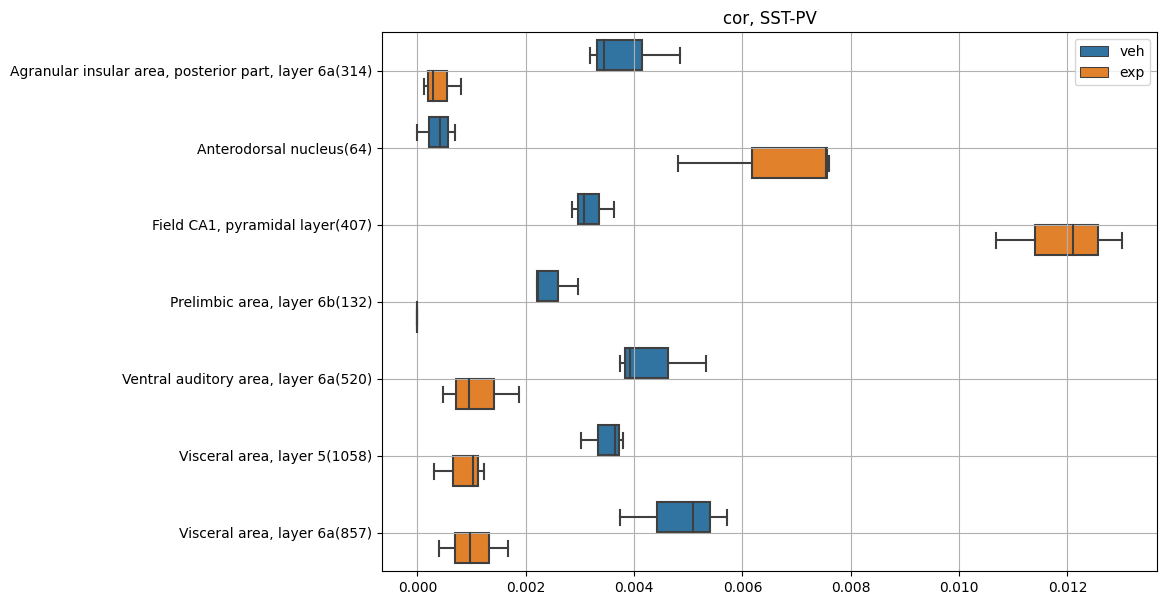

<Figure size 640x480 with 0 Axes>

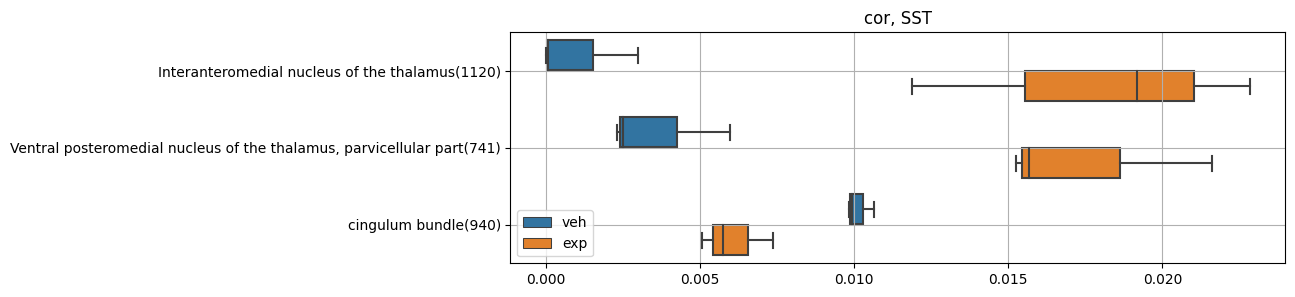

<Figure size 640x480 with 0 Axes>

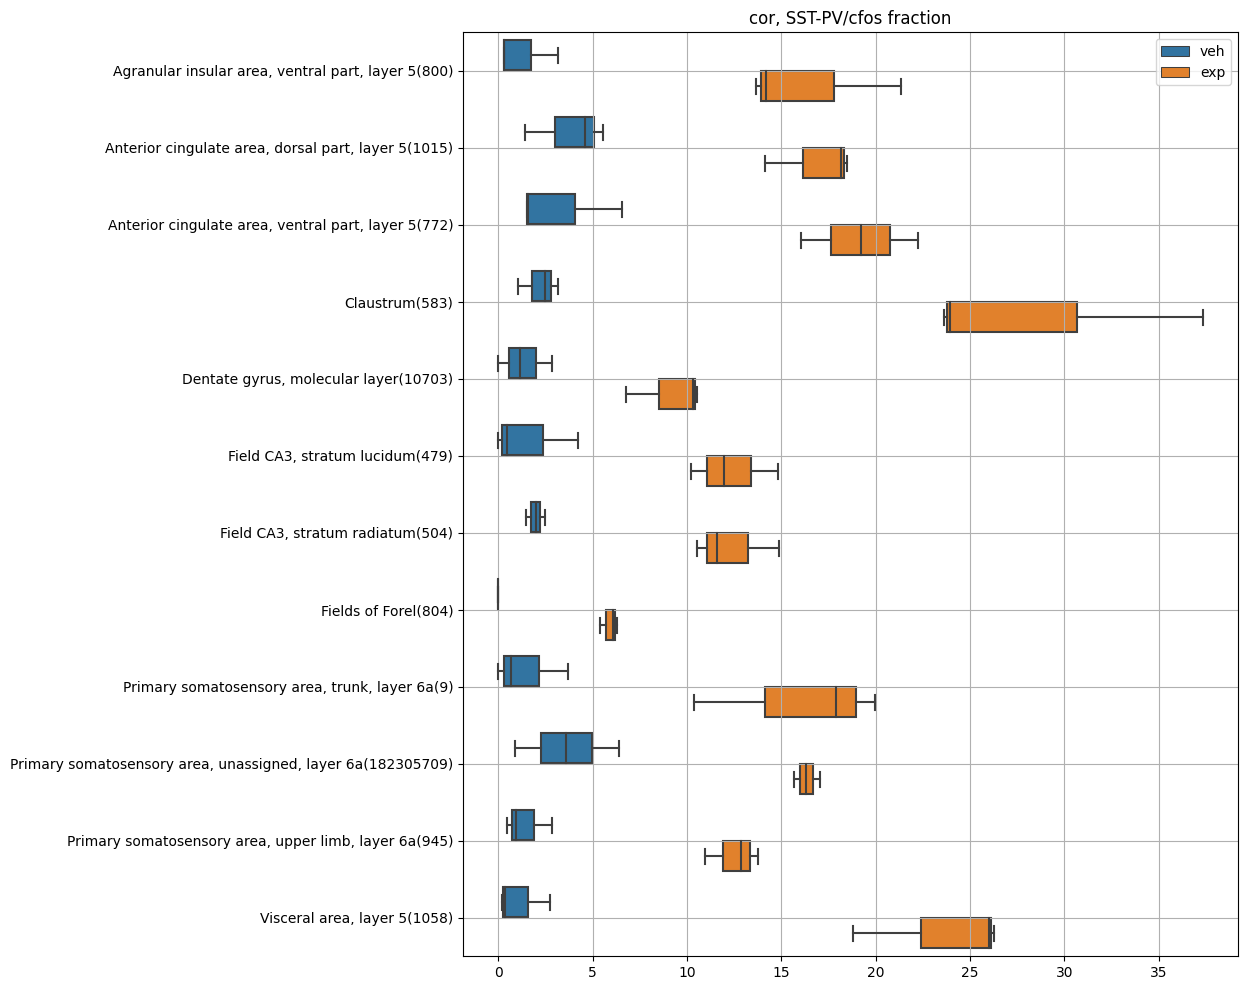

<Figure size 640x480 with 0 Axes>

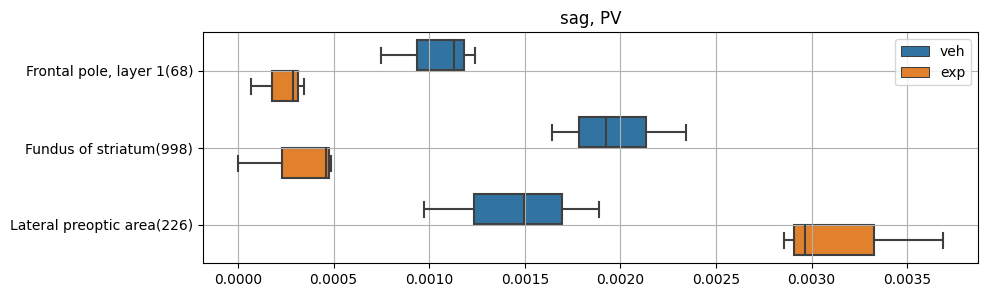

<Figure size 640x480 with 0 Axes>

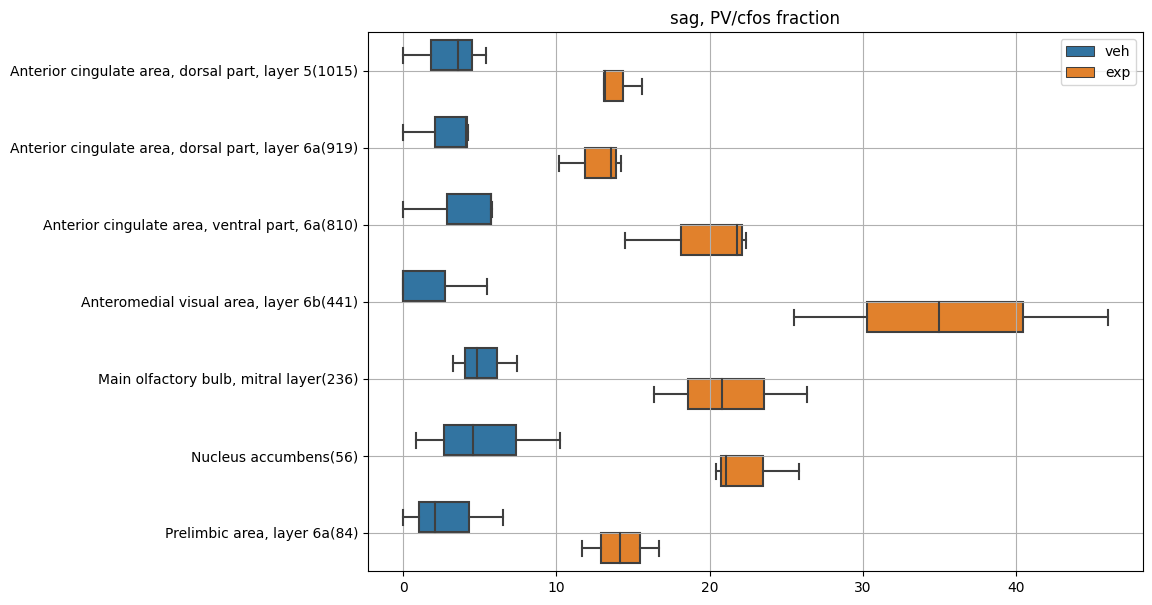

<Figure size 640x480 with 0 Axes>

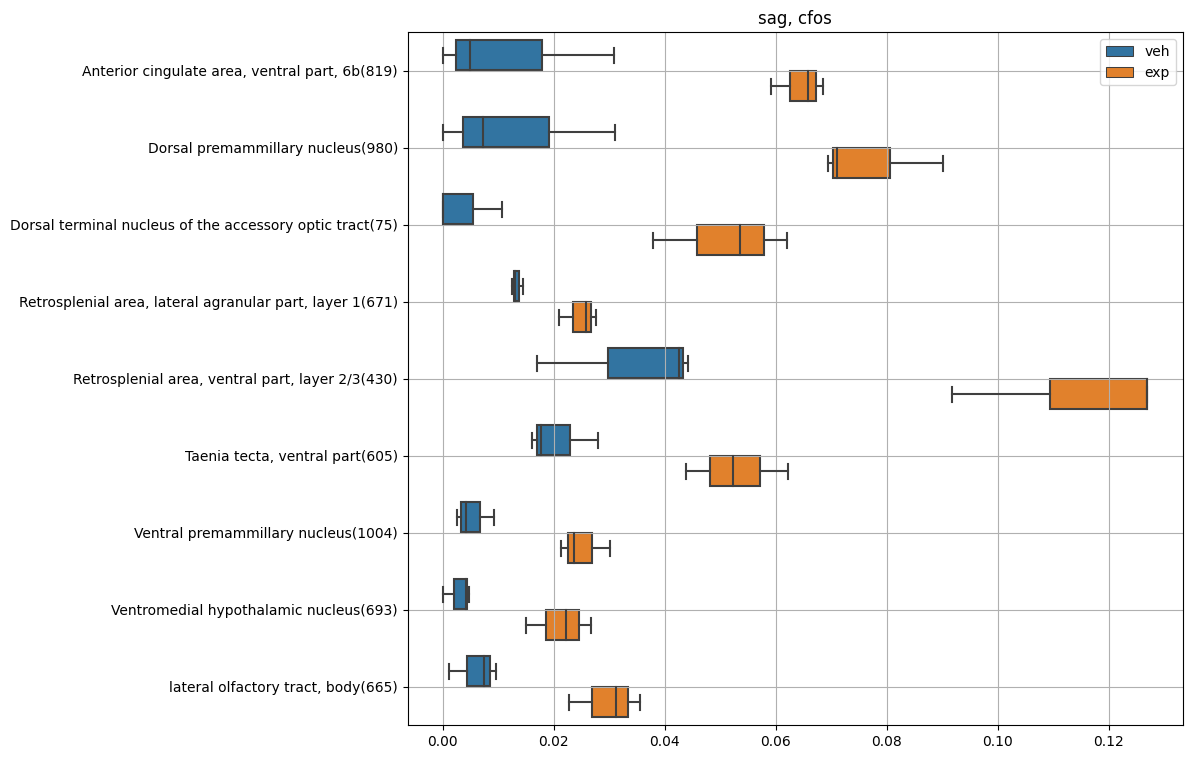

<Figure size 640x480 with 0 Axes>

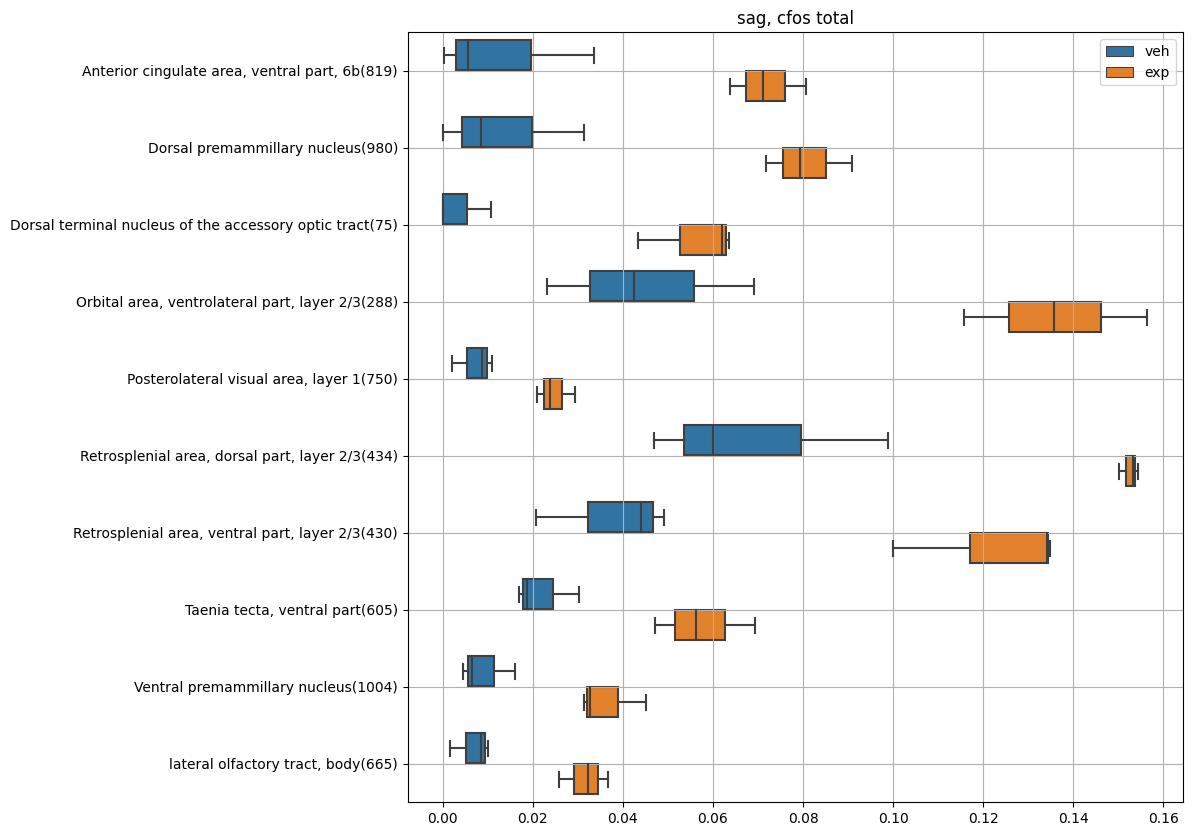

<Figure size 640x480 with 0 Axes>

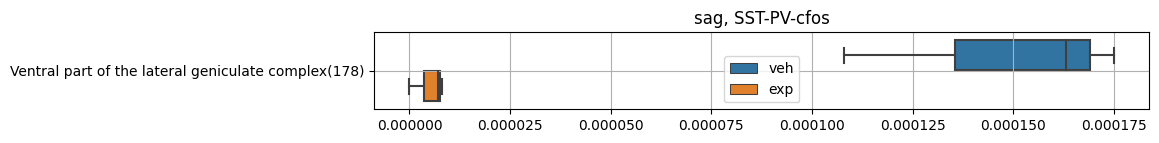

<Figure size 640x480 with 0 Axes>

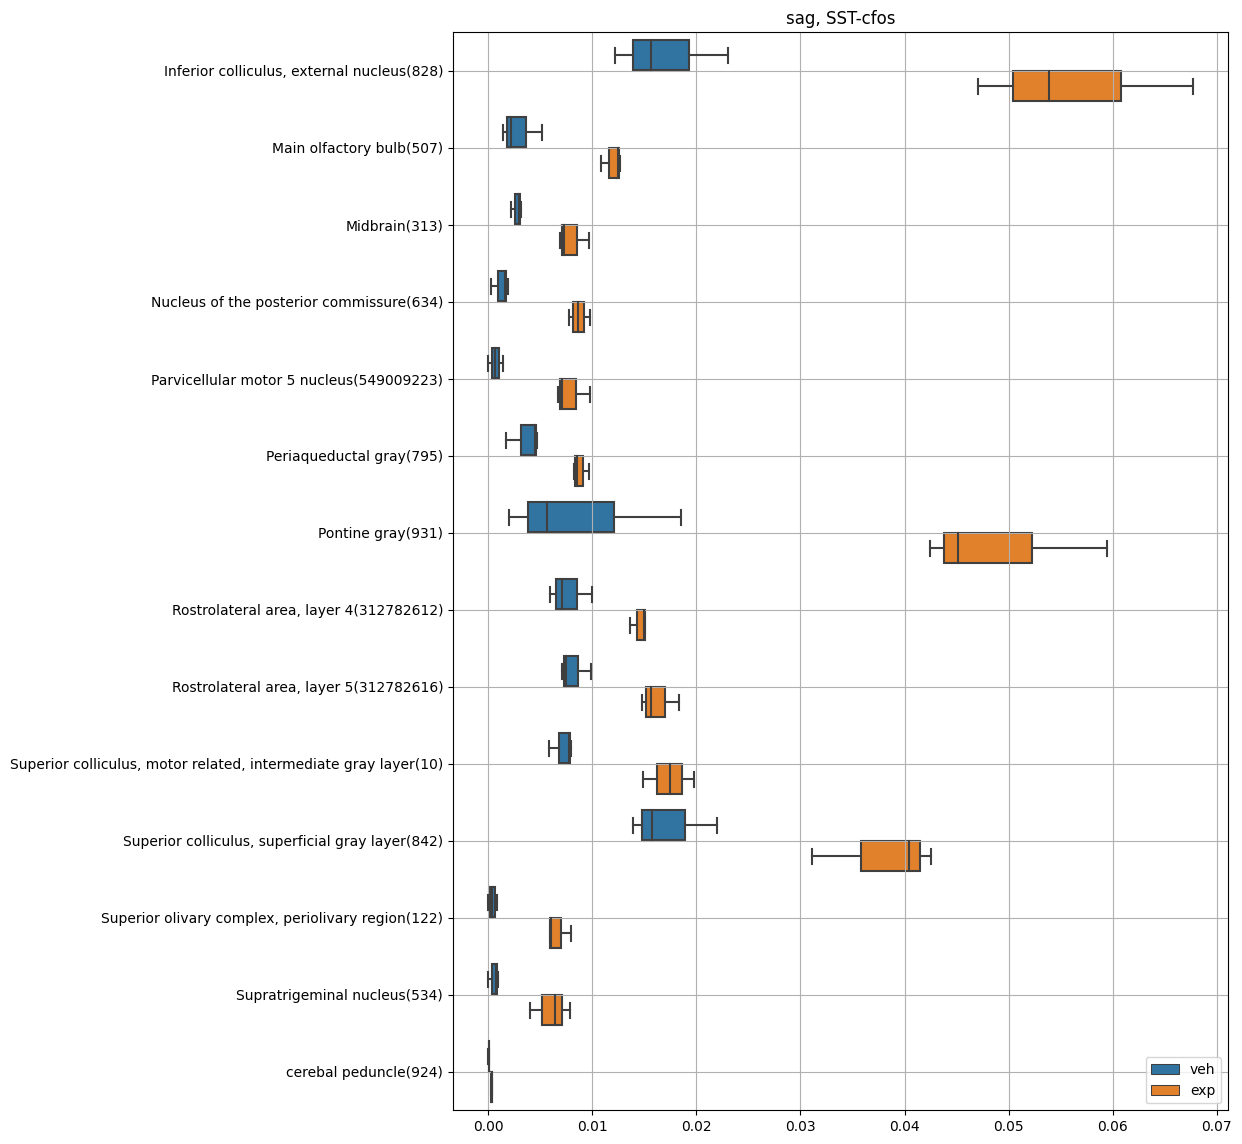

<Figure size 640x480 with 0 Axes>

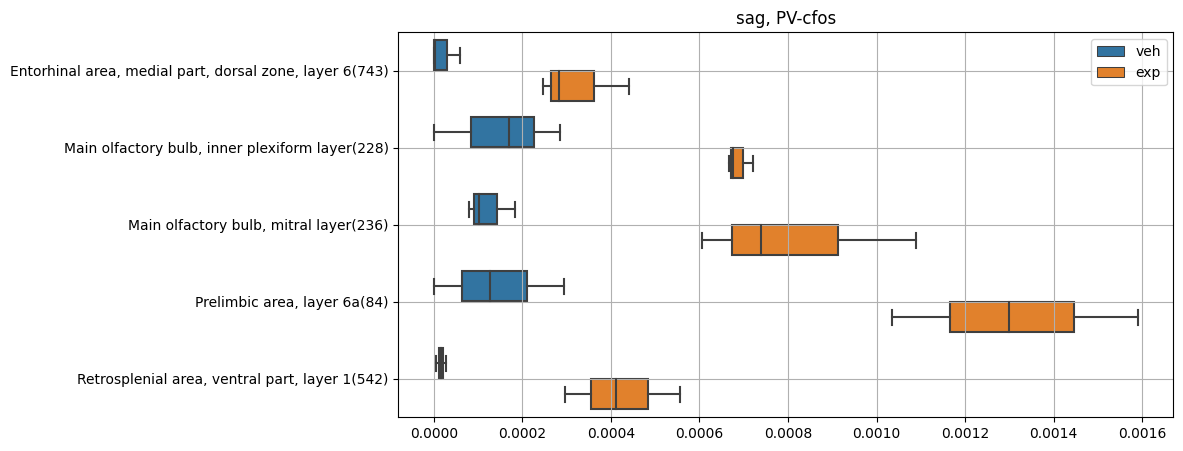

sag SST/cfos fraction


<Figure size 640x480 with 0 Axes>

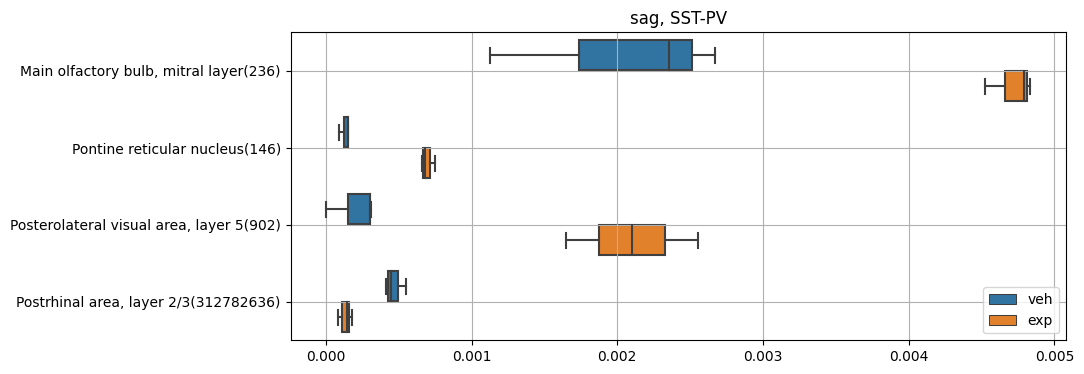

sag SST


<Figure size 640x480 with 0 Axes>

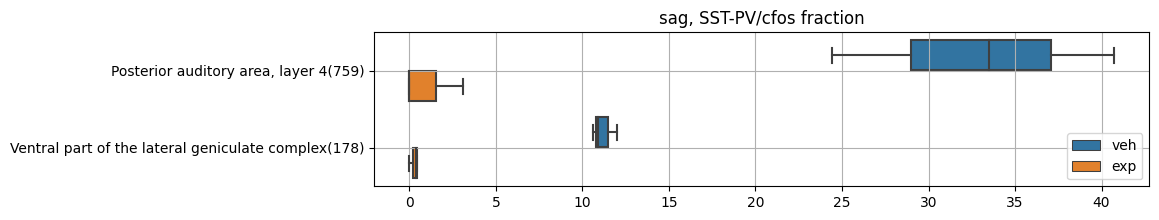

In [540]:
_cut_method = 'cor'

for _cut_method in cut_method_list:

    for _color in color_list:
    
        _ttest_df_filtered = _ttest_df.query(f'color == "{_color}" and cut_method == "{_cut_method}"')
        if len(_ttest_df_filtered) == 0:
            print(_cut_method,_color)
            continue
        _region_id_list = list(set(_ttest_df_filtered['region_id'].values))
    
        
    
        _df = df_total[df_total.index.str.endswith(_cut_method+"_"+_color)]
        _df = _df[_region_id_list + ['veh_exp']]
        _df_melt = pd.melt(_df, id_vars=['veh_exp'], value_vars=_region_id_list)
        from_to = {}
        for _r in _region_id_list:    
            from_to[_r] = G.nodes[_r]["name"] + f"({_r})"
        _df_melt = _df_melt.replace(from_to).sort_values(by='Region ID')
    
        plt.clf()  
        fig = plt.figure(figsize=(10,len(_region_id_list)*1.0))
        ax = sns.boxplot(y = 'Region ID', 
                x = 'value', 
                hue = 'veh_exp', data=_df_melt)
        ax.set(title =f'{_cut_method}, {_color}' , xlabel='', ylabel=f'')
        ax.yaxis.grid(True) # Hide the horizontal gridlines
        ax.xaxis.grid(True) # Show the vertical gridlines
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, ['veh', 'exp'], title="") 
        #plt.xticks(rotation=90)
        
        #fig.suptitle(f'{_region_id}\n', fontsize=15)
        #fig.tight_layout(h_pad=2.0)#reduces the horizontal gap
        #fig.savefig(f'output/box_{dept_col}.pdf', format='pdf', bbox_inches="tight")
        fig.savefig(f'/disk2/2024_mice/boxplot_{_cut_method}_{_color.replace("/","_").replace(" ","_")}.png', format='png', bbox_inches="tight")
        plt.show()



In [541]:
status = subprocess.check_output('cp /disk2/2024_mice/boxplot_* output', shell=True)
print(status)

b''


the number of regions with all zero


655

In [102]:
df_exp = df_exp[df_exp[df_exp.columns[3:]].sum(axis=1) != 0.0]

In [79]:
df_exp.loc[ df_exp.eq(0).sum(axis=1).index,'zero_count'] = df_exp.eq(0).sum(axis=1).values

In [122]:
df_exp[[a for a in df_exp.columns if cut+"_"+color in a]].eq(0).sum(axis=1)

1       1
8       2
9       1
10      1
11      0
       ..
1297    1
1300    1
1301    2
1302    0
1303    1
Length: 673, dtype: int64

In [133]:
_df_list = []
_df_columns = []
_df_list.append(df_exp[df_exp.columns[:3]])
_df_columns.extend(df_exp.columns[:3])
for cut in cut_method_list:
    for color in color_list:
        #_row = {}
        _df_columns.append(cut+"_"+color)
        _df_list.append(df_exp[[a for a in df_exp.columns if a.endswith(cut+"_"+color)]].eq(0).sum(axis=1))
        #_row_list.append(_row)
_df_zero_count = pd.concat(_df_list, axis=1)
_df_zero_count.columns = _df_columns
_df_zero_count

,TG number,Region ID,Region name,cor_PV,cor_cfos,cor_SST,sag_PV,sag_cfos,sag_SST
1,2,997,root,0,0,0,0,0,0
8,9,68,"Frontal pole, layer 1",1,1,1,0,0,1
9,10,667,"Frontal pole, layer 2/3",2,1,1,0,0,1
10,11,526157192,"Frontal pole, layer 5",1,1,1,0,0,0
11,12,526157196,"Frontal pole, layer 6a",0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...
1297,1298,108,choroid plexus,1,0,0,0,0,1
1300,1301,129,third ventricle,0,0,0,0,0,0
1301,1302,140,cerebral aqueduct,1,1,1,1,1,2
1302,1303,145,fourth ventricle,3,3,3,0,0,1


In [136]:
_df_zero_count[(_df_zero_count == 3).sum(axis=1) != 0]

,TG number,Region ID,Region name,cor_PV,cor_cfos,cor_SST,sag_PV,sag_cfos,sag_SST
12,13,526322264,"Frontal pole, layer 6b",3,3,3,3,1,2
121,122,849,"Visceral area, layer 6b",3,0,0,2,0,2
166,167,1074,"Anterolateral visual area, layer 1",1,0,0,3,0,1
194,195,750,"Posterolateral visual area, layer 1",2,2,3,0,0,1
196,197,869,"Posterolateral visual area, layer 4",3,2,2,0,0,1
...,...,...,...,...,...,...,...,...,...
1256,1257,449,ventral hippocampal commissure,3,2,1,1,1,1
1266,1267,349,supraoptic commissures,3,1,0,0,0,1
1282,1283,673,mammillary peduncle,3,1,1,2,0,1
1302,1303,145,fourth ventricle,3,3,3,0,0,1


In [199]:
import urllib.request, json 
with urllib.request.urlopen("http://api.brain-map.org/api/v2/structure_graph_download/1.json") as url:
    mouse_graph = json.load(url)
    #print(data)

In [384]:
json.dumps(mouse_graph).strip()


'{"success": true, "id": 0, "start_row": 0, "num_rows": 1, "total_rows": 1, "msg": [{"id": 997, "atlas_id": -1, 
"ontology_id": 1, "acronym": "root", "name": "root", "color_hex_triplet": "FFFFFF", "graph_order": 0, "st_level": 
0, "hemisphere_id": 3, "parent_structure_id": null, "children": [{"id": 8, "atlas_id": 0, "ontology_id": 1, 
"acronym": "grey", "name": "Basic cell groups and regions", "color_hex_triplet": "BFDAE3", "graph_order": 1, 
"st_level": 1, "hemisphere_id": 3, "parent_structure_id": 997, "children": [{"id": 567, "atlas_id": 70, 
"ontology_id": 1, "acronym": "CH", "name": "Cerebrum", "color_hex_triplet": "B0F0FF", "graph_order": 2, "st_level":
2, "hemisphere_id": 3, "parent_structure_id": 8, "children": [{"id": 688, "atlas_id": 85, "ontology_id": 1, 
"acronym": "CTX", "name": "Cerebral cortex", "color_hex_triplet": "B0FFB8", "graph_order": 3, "st_level": 3, 
"hemisphere_id": 3, "parent_structure_id": 567, "children": [{"id": 695, "atlas_id": 86, "ontology_id": 1, 
"acr

In [392]:
type(mouse_graph['msg'])

<class 'list'>

In [420]:
import networkx as nx
G = nx.DiGraph()
def _traverse(G, _parent, _cur):
    #print(_root)

    _name = _cur['name']
    _id = int(_cur['id'])
    G.add_node(_id, name =_name)
    
    if _parent is not None:
        G.add_edge(int(_parent['id']), _id)

    
    if 'children' not in _cur:
        return
        
    _obj_list = _cur['children']
    for _obj in _obj_list:
        
        _traverse(G, _cur, _obj)

_traverse(G, None, mouse_graph['msg'][0])
G

In [423]:
nx.ancestors(G, 68)

{997, 8, 695, 688, 567, 184, 315}

In [424]:
nx.is_directed_acyclic_graph(G)

dict(nx.tree_all_pairs_lowest_common_ancestor(G, pairs=[(1, 4), (2, 3)]))

True

In [421]:
#G.number_of_nodes()

for _c in G.neighbors(879):
    print(G.nodes[_c]['name'])

Retrosplenial area, dorsal part, layer 1
Retrosplenial area, dorsal part, layer 2/3
Retrosplenial area, dorsal part, layer 4
Retrosplenial area, dorsal part, layer 5
Retrosplenial area, dorsal part, layer 6a
Retrosplenial area, dorsal part, layer 6b


In [209]:
from jsonpath_ng import jsonpath, parse
jsonpath_expr = parse('foo[*].baz')
[match.value for match in jsonpath_expr.find(mouse_graph)]

[]

In [ ]:
for region_id in _df_zero_count['Region ID'].values:
    try:
        bg_atlas.structures[region_id]["name"]
        #pass
        #logger.info(f'{bg_atlas.structures[region_id]["name"]} / {bg_atlas.get_structure_ancestors(region_id)}')
    except:
        logger.error(f'{region_id}')

#bg_atlas.structures[567]['name']

In [ ]:
from pprint import pprint

import numpy as np

from brainglobe_atlasapi import BrainGlobeAtlas

bg_atlas = BrainGlobeAtlas("allen_mouse_25um", check_latest=False)

In [195]:
type(bg_atlas.structures)

<class 'brainglobe_atlasapi.structure_class.StructuresDict'>

In [192]:
for region_id in _df_zero_count['Region ID'].values:
    try:
        bg_atlas.structures[region_id]["name"]
        #pass
        #logger.info(f'{bg_atlas.structures[region_id]["name"]} / {bg_atlas.get_structure_ancestors(region_id)}')
    except:
        logger.error(f'{region_id}')

#bg_atlas.structures[567]['name']

2024-12-07 05:47:44,014[ERROR]: 220
2024-12-07 05:47:44,016[ERROR]: 228
2024-12-07 05:47:44,017[ERROR]: 236
2024-12-07 05:47:44,019[ERROR]: 244
2024-12-07 05:47:44,020[ERROR]: 391
2024-12-07 05:47:44,021[ERROR]: 399
2024-12-07 05:47:44,022[ERROR]: 407
2024-12-07 05:47:44,023[ERROR]: 415
2024-12-07 05:47:44,024[ERROR]: 431
2024-12-07 05:47:44,025[ERROR]: 438
2024-12-07 05:47:44,026[ERROR]: 446
2024-12-07 05:47:44,028[ERROR]: 454
2024-12-07 05:47:44,029[ERROR]: 471
2024-12-07 05:47:44,030[ERROR]: 479
2024-12-07 05:47:44,031[ERROR]: 486
2024-12-07 05:47:44,032[ERROR]: 495
2024-12-07 05:47:44,032[ERROR]: 504
